# Sales Prediction using Python

- involves forecasting the amount of a product that customers will purchase, taking into advertising platform selection.
- in businesses that offer products or services, the role of Data scientists is crucial for predicting future sales.
- utilizing machine learning techniques to analyze and interpret data, allowing them to make informed decisions regarding advertising costs
- by leveraging these predictions, business can optimize their advertising strategies and maximize sales potential


Let's analyze this dataset of sales prediction using machine learning in Python.

In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [5]:
dataset = pd.read_csv('/content/drive/MyDrive/SalesPrediction/advertising.csv')
dataset.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [6]:
dataset.tail()

,TV,Radio,Newspaper,Sales
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,18.4


In [7]:
print(dataset.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


We have no null values so let's look at correlation between features (tv with sales, radio with sales, newspaper with sales)

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


<ipython-input-11-e4534141d882>:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


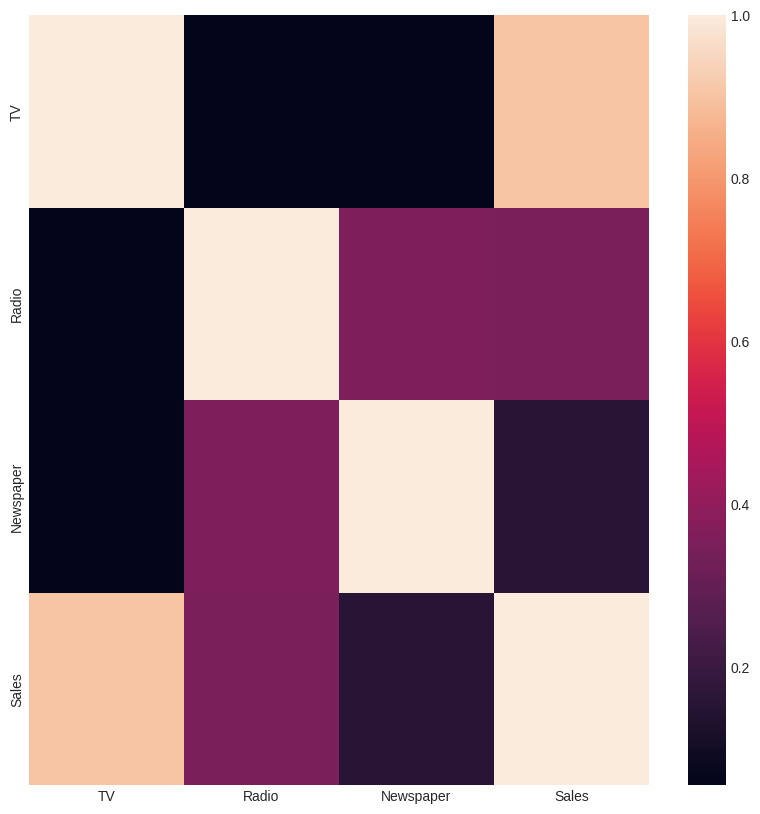

In [11]:
print(dataset.corr())
plt.style.use('seaborn-whitegrid')
plt.figure(figsize=(10, 10))
sns.heatmap(dataset.corr())
plt.show()

In [14]:
X = np.array(dataset.drop(['Sales'], 1))
y = np.array(dataset['Sales'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

data = pd.DataFrame(data={'Predicted Sales':y_pred.flatten()})
data

<ipython-input-14-0704d277c636>:1: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  X = np.array(dataset.drop(['Sales'], 1))


,Predicted Sales
0,17.159919
1,20.533695
2,23.689144
3,9.519146
4,21.607368
5,12.781013
6,21.086363
7,8.760542
8,17.115000
9,16.687896


That's one way to predict sales.

Let's look at one feature independent with sales. Let's say 'TV'.


array([[19.73726517],
       [ 9.44300377],
       [ 7.92881554],
       [15.37773421],
       [17.00285199],
       [ 7.45736499],
       [10.16404579],
       [13.6416869 ],
       [ 7.45181851],
       [18.05668263],
       [10.64104282],
       [18.88310771],
       [ 8.29488303],
       [12.38263661],
       [18.29518114],
       [17.81263764],
       [10.73533293],
       [22.5826079 ],
       [10.8129836 ],
       [15.14478218],
       [19.08832736],
       [20.142158  ],
       [ 7.70695646],
       [19.63742859],
       [10.43027669],
       [21.55650964],
       [14.90073719],
       [20.29191288],
       [20.77445638],
       [10.89063428],
       [23.22045276],
       [13.23679407],
       [12.36599718],
       [21.70626452],
       [12.28280002],
       [23.09843026],
       [21.77836873],
       [11.11803984],
       [ 9.3653531 ],
       [19.62078916],
       [18.20643751],
       [16.79208586],
       [23.2592781 ],
       [18.4504825 ],
       [ 8.36698723],
       [16

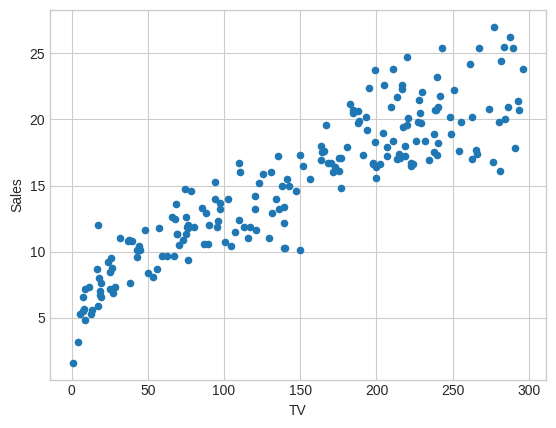

In [16]:
dataset.plot.scatter(x='TV', y='Sales')
x = dataset[['TV']]
y = dataset[['Sales']]

model = LinearRegression()
model.fit(x, y)
model.predict(x)

[6.97482149]
[[0.05546477]]


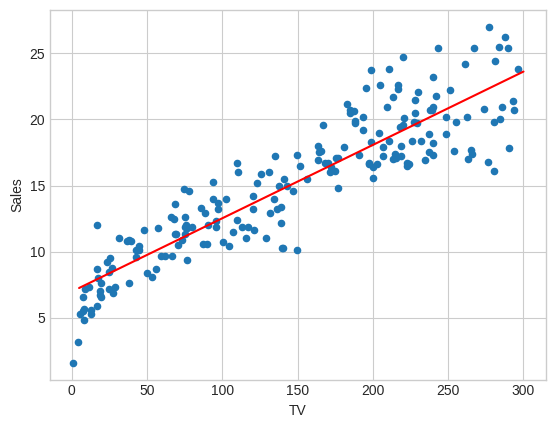

In [39]:
# extract coefficient and intercept and draw a line with that intercept and slope. Give the same graph as above.
print(model.intercept_)
print(model.coef_)
X_new = pd.DataFrame()
X_new = np.linspace(5, 300, num=300)
y_new = [(model.coef_ * i + model.intercept_) for i in X_new]
y_new = np.array(y_new).reshape(-1, 1)
# print(X_new.shape)
# print(y_new.shape)

dataset.plot.scatter(x='TV', y='Sales')
plt.plot(X_new, y_new, c='r')

# Same plot as above.


Now let's test a prediction given all 3 costs of advertising.

Fit a linear regression model that predicts the sale price using given cost of TV advertising, cost of newspaper advertising, and cost of radio advertising. Interpret the coefficients. Then, use your fitted model to predict the sale of a 200.5 cost of TV advertising, 50 cost of radio advertising, and 75 cost of newspaper advertising.

In [40]:
X_train = dataset[['TV', 'Radio', 'Newspaper']]
y_train = dataset[['Sales']]

test = pd.DataFrame({'TV':200.5, 'Radio':50.0, 'Newspaper':75.0}, index=[0])

Model = LinearRegression()
Model.fit(X_train, y_train)
print(Model.coef_)
Model.predict(X=test)


[[0.05444578 0.10700123 0.00033566]]


array([[20.91673879]])

The coefficients are rate of change for TV cost is 0.054, 0.107 for Radio, and 0.00033 for newspaper. For cost of newspaper advertisement at 200.5, 50.0 cost for radio, and 75.0 cost for newspaper, the predicted sales price is 20.91
